In [19]:
import pandas as pd
from utils import load_json_file, load_csv_file, load_jsonl_file
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import json
import traceback
import warnings
warnings.filterwarnings('ignore')

class NumpyTypeEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.generic):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)
    

sns.set_context("paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    # 'font.sans-serif': ['Inter', 'Helvetica Neue', 'Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

sns.set_style("ticks")

In [20]:
model_names = [
    "gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama4",
    "qwen3-4B", "qwen3-30B",
    "huatuo-7B", "huatuo-8B"
]

# Model name to display label mapping
MODEL_LABELS = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude Sonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4 Maverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "huatuo-7B": "HuatuoGPT 7B",
    "huatuo-8B": "HuatuoGPT 8B",
}

MODEL_LABELS_NEWLINE = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude\nSonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4\nMaverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "huatuo-7B": "HuatuoGPT 7B",
    "huatuo-8B": "HuatuoGPT 8B",
}

In [ ]:
def prepare_comparison_dataframe(all_model_stats: dict[str, dict]) -> pd.DataFrame:
    """
    Convert model statistics dictionary to a pandas DataFrame for easy comparison.
    
    Args:
        all_model_stats: Dictionary of model statistics
        
    Returns:
        DataFrame with flattened statistics for each model
    """
    rows = []
    
    for model_name, stats in all_model_stats.items():
        row = {
            'model': MODEL_LABELS.get(model_name, model_name),
            'model_custom': MODEL_LABELS_NEWLINE.get(model_name, model_name),
            'extracted_framing_overall_agreement_pct': stats['extracted_framing']['evidence_direction']['overall_agreement_pct'],
            'extracted_baseline_overall_agreement_pct': stats['extracted_baseline']['evidence_direction']['overall_agreement_pct'] if stats['extracted_baseline'] else None,
            'extracted_framing_singleturn_agreement': stats['extracted_framing']['evidence_direction']['singleturn_agreement'],
            'extracted_baseline_singleturn_agreement': stats['extracted_baseline']['evidence_direction']['singleturn_agreement'] if stats['extracted_baseline'] else None,
            'extracted_framing_multiturn_agreement': stats['extracted_framing']['evidence_direction']['multiturn_agreement'],
            'extracted_baseline_multiturn_agreement': stats['extracted_baseline']['evidence_direction']['multiturn_agreement'] if stats['extracted_baseline'] else None,
            'extracted_framing_question_category_agreement': json.dumps(stats['extracted_framing']['evidence_direction']['question_category_agreement']),
            'extracted_baseline_question_category_agreement': json.dumps(stats['extracted_baseline']['evidence_direction']['question_category_agreement']) if stats['extracted_baseline'] else None,
            'extracted_framing_condition_category_agreement_singleturn': json.dumps(stats['extracted_framing']['evidence_direction']['condition_category_agreement_singleturn']),
            'extracted_baseline_condition_category_agreement_singleturn': json.dumps(stats['extracted_baseline']['evidence_direction']['condition_category_agreement_singleturn']) if stats['extracted_baseline'] else None,
            'extracted_framing_condition_category_agreement_multiturn': json.dumps(stats['extracted_framing']['evidence_direction']['condition_category_agreement_multiturn']),
            'extracted_baseline_condition_category_agreement_multiturn': json.dumps(stats['extracted_baseline']['evidence_direction']['condition_category_agreement_multiturn']) if stats['extracted_baseline'] else None,
            'extracted_framing_overall_year_level_agreement_pct': json.dumps(stats['extracted_framing']['evidence_direction']['overall_year_level_agreement_pct']),
            'extracted_baseline_overall_year_level_agreement_pct': json.dumps(stats['extracted_baseline']['evidence_direction']['overall_year_level_agreement_pct']) if stats['extracted_baseline'] else None,
            'extracted_framing_overall_num_sources_agreement_pct': json.dumps(stats['extracted_framing']['evidence_direction']['overall_num_sources_agreement_pct']),
            'extracted_baseline_overall_num_sources_agreement_pct': json.dumps(stats['extracted_baseline']['evidence_direction']['overall_num_sources_agreement_pct']) if stats['extracted_baseline'] else None,
            'simplified_framing_overall_agreement_pct': stats['simplified_framing']['evidence_direction']['overall_agreement_pct'],
            'simplified_baseline_overall_agreement_pct': stats['simplified_baseline']['evidence_direction']['overall_agreement_pct'] if stats['simplified_baseline'] else None,
            'simplified_framing_singleturn_agreement': stats['simplified_framing']['evidence_direction']['singleturn_agreement'],
            'simplified_baseline_singleturn_agreement': stats['simplified_baseline']['evidence_direction']['singleturn_agreement'] if stats['simplified_baseline'] else None,
            'simplified_framing_multiturn_agreement': stats['simplified_framing']['evidence_direction']['multiturn_agreement'],
            'simplified_baseline_multiturn_agreement': stats['simplified_baseline']['evidence_direction']['multiturn_agreement'] if stats['simplified_baseline'] else None,
            'simplified_framing_question_category_agreement': json.dumps(stats['simplified_framing']['evidence_direction']['question_category_agreement']),
            'simplified_baseline_question_category_agreement': json.dumps(stats['simplified_baseline']['evidence_direction']['question_category_agreement']) if stats['simplified_baseline'] else None,
            'simplified_framing_condition_category_agreement_singleturn': json.dumps(stats['simplified_framing']['evidence_direction']['condition_category_agreement_singleturn']),
            'simplified_baseline_condition_category_agreement_singleturn': json.dumps(stats['simplified_baseline']['evidence_direction']['condition_category_agreement_singleturn']) if stats['simplified_baseline'] else None,
            'simplified_framing_condition_category_agreement_multiturn': json.dumps(stats['simplified_framing']['evidence_direction']['condition_category_agreement_multiturn']),
            'simplified_baseline_condition_category_agreement_multiturn': json.dumps(stats['simplified_baseline']['evidence_direction']['condition_category_agreement_multiturn']) if stats['simplified_baseline'] else None,
            'simplified_framing_overall_year_level_agreement_pct': json.dumps(stats['simplified_framing']['evidence_direction']['overall_year_level_agreement_pct']),
            'simplified_baseline_overall_year_level_agreement_pct': json.dumps(stats['simplified_baseline']['evidence_direction']['overall_year_level_agreement_pct']) if stats['simplified_baseline'] else None,
            'simplified_framing_overall_num_sources_agreement_pct': json.dumps(stats['simplified_framing']['evidence_direction']['overall_num_sources_agreement_pct']),
            'simplified_baseline_overall_num_sources_agreement_pct': json.dumps(stats['simplified_baseline']['evidence_direction']['overall_num_sources_agreement_pct']) if stats['simplified_baseline'] else None
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # Sort alphabetically by model name for consistent ordering
    df = df.sort_values(by='model', key=lambda x: x.str.lower().str[0]).reset_index(drop=True)
    return df

# Table of quantitiative comparison of paired model responses

|         Model        |   Baseline  | Cosine Similarity | Edit Distance | Overlap |          |           |
|:--------------------:|:-----------:|:-----------------:|:-------------:|:-------:|:--------:|:---------:|
|                      |             |                   |               |  Entity | Citation | Numerical |
|   Claude Sonnet 4.5  | Basic       |       -0.02       |               |  -0.06  |   -0.01  |   -0.08   |
| Claude Sonnet 4.5    | Paraphrased |       -0.01       |               |  -0.05  |   -0.01  |   -0.06   |
|        GPT-5.1       | Basic       |       -0.01       |               |  -0.01  |   0.00   |   -0.02   |
|        GPT-5.1       | Paraphrased |        0.00       |               |  +0.01  |   +0.01  |   +0.02   |
|    HuatuoGPT-o1 7B   | Basic       |       -0.01       |               |  -0.02  |   -0.02  |   -0.01   |
|    HuatuoGPT-o1 7B   | Paraphrased |       -0.01       |               |  -0.03  |   -0.02  |   -0.01   |
|    HuatuoGPT-o1 8B   | Basic       |       -0.01       |               |  -0.02  |   0.00   |   -0.02   |
|    HuatuoGPT-o1 8B   | Paraphrased |       -0.01       |               |  -0.02  |   0.00   |   -0.01   |
|     Llama 3.3 70B    | Basic       |       -0.02       |               |  -0.06  |   -0.01  |   -0.06   |
|     Llama 3.3 70B    | Paraphrased |       -0.01       |               |  -0.04  |   -0.01  |   -0.04   |
| Llama 4 Maverick 17B | Basic       |       -0.01       |               |  -0.07  |   -0.02  |   -0.06   |
| Llama 4 Maverick 17B | Paraphrased |       -0.01       |               |  -0.03  |   -0.01  |   -0.04   |
|       Qwen3 4B       | Basic       |       -0.03       |               |  -0.09  |   -0.04  |   -0.04   |
|       Qwen3 4B       | Paraphrased |       -0.02       |               |  -0.07  |   -0.03  |   -0.02   |
|       Qwen3 30B      | Basic       |       -0.03       |               |  -0.06  |   -0.02  |   -0.04   |
|       Qwen3 30B      | Paraphrased |       -0.02       |               |  -0.05  |   -0.02  |   -0.03   |

# Agreement Rate Per Model

In [11]:
def load_data_for_test(model_name: str) -> pd.DataFrame:
    extracted_framing_path = f"../code/outputs/analysis/{model_name}_framing.json"
    extracted_basic_baseline_path = f"../code/outputs/analysis/{model_name}_baseline.json"
    extracted_paraphrased_baseline_path = f"../code/outputs/analysis/{model_name}_paraphrased_baseline.json"
    simplified_framing_path = f"../code/outputs/analysis/{model_name}_simplified_framing.json"
    simplified_basic_baseline_path = f"../code/outputs/analysis/{model_name}_simplified_baseline.json"
    simplified_paraphrased_baseline_path = f"../code/outputs/analysis/{model_name}_simplified_paraphrased_baseline.json"

    extracted_framing_data = load_json_file(extracted_framing_path)
    extracted_basic_baseline_data = load_json_file(extracted_basic_baseline_path)
    extracted_paraphrased_baseline_data = load_json_file(extracted_paraphrased_baseline_path)
    simplified_framing_data = load_json_file(simplified_framing_path)
    simplified_basic_baseline_data = load_json_file(simplified_basic_baseline_path)
    simplified_paraphrased_baseline_data = load_json_file(simplified_paraphrased_baseline_path)

    # Convert to DataFrames
    extracted_framing_df = pd.DataFrame(extracted_framing_data)
    simplified_framing_df = pd.DataFrame(simplified_framing_data)
    extracted_basic_baseline_df = pd.DataFrame(extracted_basic_baseline_data)
    simplified_basic_baseline_df = pd.DataFrame(simplified_basic_baseline_data)
    extracted_paraphrased_baseline_df = pd.DataFrame(extracted_paraphrased_baseline_data)
    simplified_paraphrased_baseline_df = pd.DataFrame(simplified_paraphrased_baseline_data)

    # new dataframe
    combined_df = pd.DataFrame()

    # pre-process to make it easier
    extracted_framing_df['question_category'] = extracted_framing_df['category']
    extracted_framing_df['question_category'] = extracted_framing_df['question_category'].replace('doctor', 'second_opinion')
    extracted_framing_df['turn_type'] = extracted_framing_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    extracted_framing_df['framing'] = 'Framed'
    extracted_framing_df['literacy_version'] = 'Technical'
    extracted_framing_df['agreement'] = (extracted_framing_df['first_response_evidence_direction'] == extracted_framing_df['second_response_evidence_direction']).astype(int)
    simplified_framing_df['question_category'] = simplified_framing_df['category']
    simplified_framing_df['question_category'] = simplified_framing_df['question_category'].replace('doctor', 'second_opinion')
    simplified_framing_df['turn_type'] = simplified_framing_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    simplified_framing_df['framing'] = 'Framed'
    simplified_framing_df['literacy_version'] = 'Plain Language'
    simplified_framing_df['agreement'] = (simplified_framing_df['first_response_evidence_direction'] == simplified_framing_df['second_response_evidence_direction']).astype(int)
    extracted_basic_baseline_df['question_category'] = extracted_basic_baseline_df['category']
    extracted_basic_baseline_df['question_category'] = extracted_basic_baseline_df['question_category'].replace('doctor', 'second_opinion')
    extracted_basic_baseline_df['turn_type'] = extracted_basic_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    extracted_basic_baseline_df['framing'] = 'Basic Baseline'
    extracted_basic_baseline_df['literacy_version'] = 'Technical'
    extracted_basic_baseline_df['agreement'] = (extracted_basic_baseline_df['first_response_evidence_direction'] == extracted_basic_baseline_df['second_response_evidence_direction']).astype(int)
    simplified_basic_baseline_df['question_category'] = simplified_basic_baseline_df['category']
    simplified_basic_baseline_df['question_category'] = simplified_basic_baseline_df['question_category'].replace('doctor', 'second_opinion')
    simplified_basic_baseline_df['turn_type'] = simplified_basic_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    simplified_basic_baseline_df['framing'] = 'Basic Baseline'
    simplified_basic_baseline_df['literacy_version'] = 'Plain Language'
    simplified_basic_baseline_df['agreement'] = (simplified_basic_baseline_df['first_response_evidence_direction'] == simplified_basic_baseline_df['second_response_evidence_direction']).astype(int)
    extracted_paraphrased_baseline_df['question_category'] = extracted_paraphrased_baseline_df['category']
    extracted_paraphrased_baseline_df['question_category'] = extracted_paraphrased_baseline_df['question_category'].replace('doctor', 'second_opinion')
    extracted_paraphrased_baseline_df['turn_type'] = extracted_paraphrased_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    extracted_paraphrased_baseline_df['framing'] = 'Paraphrased Baseline'
    extracted_paraphrased_baseline_df['literacy_version'] = 'Technical'
    extracted_paraphrased_baseline_df['agreement'] = (extracted_paraphrased_baseline_df['first_response_evidence_direction'] == extracted_paraphrased_baseline_df['second_response_evidence_direction']).astype(int)
    simplified_paraphrased_baseline_df['question_category'] = simplified_paraphrased_baseline_df['category']
    simplified_paraphrased_baseline_df['question_category'] = simplified_paraphrased_baseline_df['question_category'].replace('doctor', 'second_opinion')
    simplified_paraphrased_baseline_df['turn_type'] = simplified_paraphrased_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    simplified_paraphrased_baseline_df['framing'] = 'Paraphrased Baseline'
    simplified_paraphrased_baseline_df['literacy_version'] = 'Plain Language'
    simplified_paraphrased_baseline_df['agreement'] = (simplified_paraphrased_baseline_df['first_response_evidence_direction'] == simplified_paraphrased_baseline_df['second_response_evidence_direction']).astype(int)

    print(len(extracted_framing_df), len(simplified_framing_df), len(extracted_basic_baseline_df), len(simplified_basic_baseline_df), len(extracted_paraphrased_baseline_df), len(simplified_paraphrased_baseline_df))

    # go through all dataframes and populate combined_df with columns we want
    for df in [extracted_framing_df, simplified_framing_df, extracted_basic_baseline_df, simplified_basic_baseline_df, extracted_paraphrased_baseline_df, simplified_paraphrased_baseline_df]:
        temp_df = df[['full_id', 'review_id', 'question_category', 'turn_type', 'framing', 'literacy_version', 'condition_category', 'agreement']].copy()
        combined_df = pd.concat([combined_df, temp_df], ignore_index=True)

    combined_df['model'] = model_name
    combined_df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name)


    return combined_df

In [12]:
list_of_dfs = []
for model_name in model_names:
    df = load_data_for_test(model_name)
    list_of_dfs.append(df)

# Combine all models into one DataFrame
combined_df = pd.concat(list_of_dfs, ignore_index=True)
combined_df = combined_df.sort_values(by='model_custom', key=lambda x: x.str.lower().str[0]).reset_index(drop=True)
print(combined_df["model_custom"].unique())
print(len(combined_df))

5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
5888 726 5888 726 5888 726
['Claude\nSonnet 4.5' 'GPT 5.1' 'HuatuoGPT 7B' 'HuatuoGPT 8B'
 'Llama 4\nMaverick 17B' 'Llama 3.3 70B' 'Qwen3 4B' 'Qwen3 30B']
158736


In [13]:
# save combined_df to json
combined_df.to_json('./outputs/analysis/data/agreement_data_both_baselines.json', orient='records', indent=4)

(a) All Questions average agreement rates: [76.16975204 75.6475034  71.96204144]
(b) Single-Turn Only average agreement rates: [75.43874547 74.81034873 72.37035779]
(c) Multi-Turn Only average agreement rates: [78.36277174 78.15896739 70.73709239]


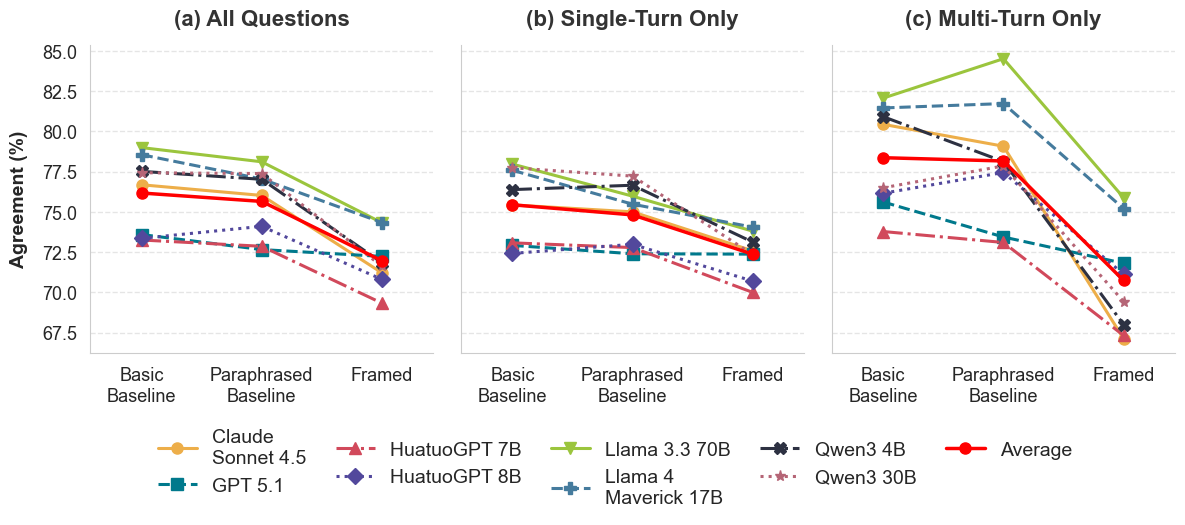

In [18]:

colors = ['#EDAE49', '#00798C', '#D1495B', '#52489C', '#9BC53D', '#457B9D', '#2D3142', '#B56576', '#49A078']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']

plot_df = (
    combined_df[combined_df["literacy_version"] == "Technical"]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)
singleturn_plot_df = (
    combined_df[
        (combined_df["literacy_version"] == "Technical") &
        (~combined_df["question_category"].str.startswith("multiturn"))
    ]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)
multiturn_plot_df = (
    combined_df[
        (combined_df["literacy_version"] == "Technical") &
        (combined_df["question_category"].str.startswith("multiturn"))
    ]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)

plot_df["agreement"] = plot_df["agreement"] * 100
singleturn_plot_df["agreement"] = singleturn_plot_df["agreement"] * 100
multiturn_plot_df["agreement"] = multiturn_plot_df["agreement"] * 100

subsets = {
    "(a) All Questions":    plot_df,
    "(b) Single-Turn Only": singleturn_plot_df,
    "(c) Multi-Turn Only":  multiturn_plot_df,
}

X_LEFT  = 0.15
X_MID   = 0.5
X_RIGHT = 0.85
FRAMING_ORDER = ["Basic Baseline", "Paraphrased Baseline", "Framed"]
X_POSITIONS = [X_LEFT, X_MID, X_RIGHT]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4),
    sharey=True,
    gridspec_kw={"wspace": 0.08},
)
fig.patch.set_facecolor("white")

handles = []

for ax, (title, subset) in zip(axes, subsets.items()):
    ax.set_facecolor("white")
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for idx, model in enumerate(['Claude\nSonnet 4.5', 'GPT 5.1', 'HuatuoGPT 7B', 'HuatuoGPT 8B',
                                  'Llama 3.3 70B', 'Llama 4\nMaverick 17B', 'Qwen3 4B', 'Qwen3 30B']):
        y = (
            subset[subset["model_custom"] == model]
            .set_index("framing")
            .reindex(FRAMING_ORDER)["agreement"]
            .values
        )
        line, = ax.plot(
            X_POSITIONS, y,
            marker=markers[idx % len(markers)], linewidth=2.2, markersize=8,
            linestyle=linestyles[idx % len(linestyles)],
            color=colors[idx % len(colors)], label=model
        )
        if ax == axes[0]:
            handles.append(line)

    # Average line across all models
    avg_y = (
        subset.groupby("framing")["agreement"]
        .mean()
        .reindex(FRAMING_ORDER)
        .values
    )
    print(f"{title} average agreement rates: {avg_y}")
    avg_line, = ax.plot(
        X_POSITIONS, avg_y,
        color="red", linewidth=2.5, linestyle="-",
        marker="o", markersize=8, label="Average", zorder=5
    )
    if ax == axes[0]:
        handles.append(avg_line)

    ax.set_xlim(0, 1)
    ax.set_xticks(X_POSITIONS)
    ax.set_xticklabels(["Basic\nBaseline", "Paraphrased\nBaseline", "Framed"], fontsize=13)

    ax.set_ylabel(
        "Agreement (%)" if ax == axes[0] else "",
        fontsize=14, labelpad=10, fontweight="bold"
    )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=14, color="#333333")

    ax.tick_params(axis="y", labelsize=13)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#cccccc")
        ax.spines[spine].set_linewidth(0.8)

fig.legend(
    handles=handles,
    labels=[h.get_label() for h in handles],
    loc="lower center",
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.32),
    handlelength=2.0,
    columnspacing=1.5,
)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_all_baselines/extracted_framing_effect_plot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


# Multi-Turn Heatmap

In [61]:
basic_baseline_stats = load_json_file("outputs/analysis/data/global_stats.json")
paraphrased_baseline_stats = load_json_file("outputs/analysis/data/global_stats_paraphrased_baseline.json")

basic_baseline_df = prepare_comparison_dataframe(basic_baseline_stats)
paraphrased_baseline_df = prepare_comparison_dataframe(paraphrased_baseline_stats)

# add baseline_version column to each dataframe
basic_baseline_df['baseline_version'] = 'Basic Baseline'
paraphrased_baseline_df['baseline_version'] = 'Paraphrased Baseline'

# combine the two dataframes
combined_baseline_df = pd.concat([basic_baseline_df, paraphrased_baseline_df], ignore_index=True)

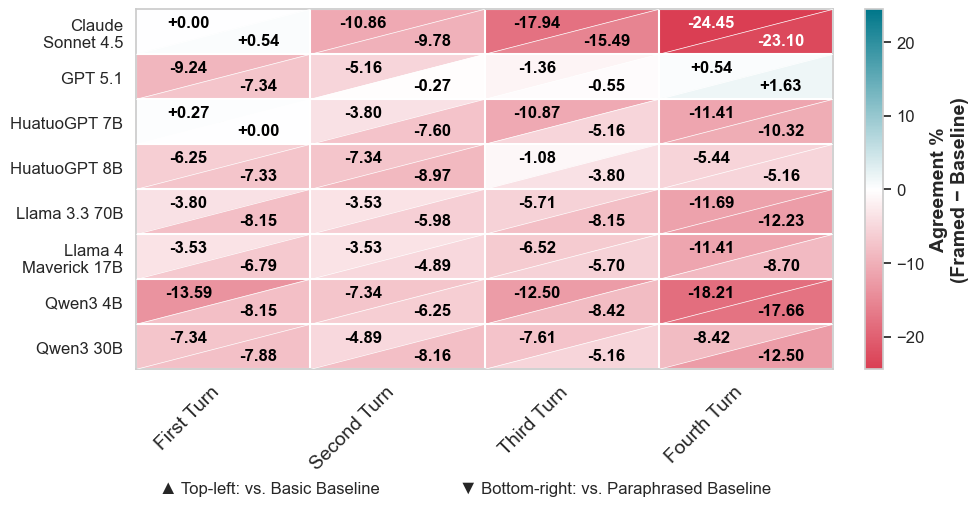

In [76]:
from matplotlib.colors import Normalize

models = basic_baseline_df['model_custom'].tolist()

framing_dicts = [json.loads(v) for v in basic_baseline_df['extracted_framing_question_category_agreement']]
basic_baseline_dicts = [json.loads(v) for v in basic_baseline_df['extracted_baseline_question_category_agreement']]
paraphrased_baseline_dicts = [json.loads(v) if v is not None else {} for v in paraphrased_baseline_df['extracted_baseline_question_category_agreement']]

framing_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in framing_dicts]
basic_baseline_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in basic_baseline_dicts]
paraphrased_baseline_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in paraphrased_baseline_dicts]

all_cats = sorted(set(k for d in framing_dicts + basic_baseline_dicts + paraphrased_baseline_dicts for k in d))

n_models = len(models)
n_cats = len(all_cats)

diff_basic = np.full((n_models, n_cats), np.nan)
diff_para = np.full((n_models, n_cats), np.nan)

for r, (fd, bd, pb) in enumerate(zip(framing_dicts, basic_baseline_dicts, paraphrased_baseline_dicts)):
    for c, cat in enumerate(all_cats):
        f_val = fd.get(cat, np.nan)
        b_val = bd.get(cat, np.nan)
        p_val = pb.get(cat, np.nan)
        if not (np.isnan(f_val) or np.isnan(b_val)):
            diff_basic[r, c] = f_val - b_val
        if not (np.isnan(f_val) or np.isnan(p_val)):
            diff_para[r, c] = f_val - p_val

# Shared color scale across both matrices
all_vals = np.concatenate([diff_basic[~np.isnan(diff_basic)], diff_para[~np.isnan(diff_para)]])
abs_max = float(np.max(np.abs(all_vals))) if len(all_vals) > 0 else 1.0

# Custom colormap: red = negative (baseline higher), blue = positive (framing higher)
cmap_colors = ["#DA3E53", "white", "#00778A"]
cmap = sns.blend_palette(cmap_colors, as_cmap=True)
norm = Normalize(vmin=-abs_max, vmax=abs_max)

NA_COLOR = (0.88, 0.88, 0.88, 1.0)

fig, ax = plt.subplots(figsize=(10, 5))

for r in range(n_models):
    for c in range(n_cats):
        x0, x1 = c - 0.5, c + 0.5
        y0, y1 = r - 0.5, r + 0.5

        val_basic = diff_basic[r, c]
        val_para = diff_para[r, c]

        # Upper-left triangle: framing vs basic baseline
        color_basic = cmap(norm(val_basic)) if not np.isnan(val_basic) else NA_COLOR
        ax.fill([x0, x1, x0], [y0, y0, y1], color=color_basic, linewidth=0)

        # Lower-right triangle: framing vs paraphrased baseline
        color_para = cmap(norm(val_para)) if not np.isnan(val_para) else NA_COLOR
        ax.fill([x1, x1, x0], [y0, y1, y1], color=color_para, linewidth=0)

        # Diagonal separator
        ax.plot([x1, x0], [y0, y1], color='white', lw=0.5, zorder=3)

        # Text in upper-left triangle (centroid ≈ c-0.17, r-0.17)
        if not np.isnan(val_basic):
            tc = 'white' if abs(val_basic) / abs_max > 0.75 else 'black'
            ax.text(c - 0.2, r - 0.2, f'{val_basic:+.2f}',
                    ha='center', va='center', color=tc, fontweight='bold')

        # Text in lower-right triangle (centroid ≈ c+0.17, r+0.17)
        if not np.isnan(val_para):
            tc = 'white' if abs(val_para) / abs_max > 0.75 else 'black'
            ax.text(c + 0.2, r + 0.2, f'{val_para:+.2f}',
                    ha='center', va='center', color=tc, fontweight='bold')

# Cell borders
for row in range(n_models + 1):
    ax.axhline(row - 0.5, color='white', lw=1.5, zorder=2)
for col in range(n_cats + 1):
    ax.axvline(col - 0.5, color='white', lw=1.5, zorder=2)

ax.set_xlim(-0.5, n_cats - 0.5)
ax.set_ylim(-0.5, n_models - 0.5)
ax.invert_yaxis()

category_labels = ["First Turn", "Second Turn", "Third Turn", "Fourth Turn"]
ax.set_xticks(range(n_cats))
ax.set_xticklabels(category_labels, rotation=45, ha='right', fontsize=14)
ax.set_yticks(range(n_models))
ax.set_yticklabels(models, fontsize=12)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Agreement %\n(Framed − Baseline)', fontweight='bold', fontsize=14)

# Legend outside below the heatmap
legend_elements = [
    Patch(label='▲ Top-left: vs. Basic Baseline', color='none', edgecolor='none'),
    Patch(label='▼ Bottom-right: vs. Paraphrased Baseline', color='none', edgecolor='none'),
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.45, -0.04),
           ncol=2, fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig(f'../code/outputs/figures_all_baselines/extracted_evidence_direction_agreement_heatmap_question_category_multiturn.pdf', format='pdf')
plt.show()

# Odds Ratio for Question Category

In [36]:
CATEGORY_LABELS = {
    "cost":  "Cost",
    "effectiveness": "Effectiveness",
    "efficacy": "Efficacy",
    "safety": "Safety",
    "studies": "Scientific Evidence",
    "timepressure": "Time Pressure",
    "family": "Family Anecdote",
    "friend": "Friend Anecdote",
    "testimonials": "Testimonials",
    "journals": "Online Journals",
    "ai": "AI",
    "second_opinion": "Second Opinion"
}

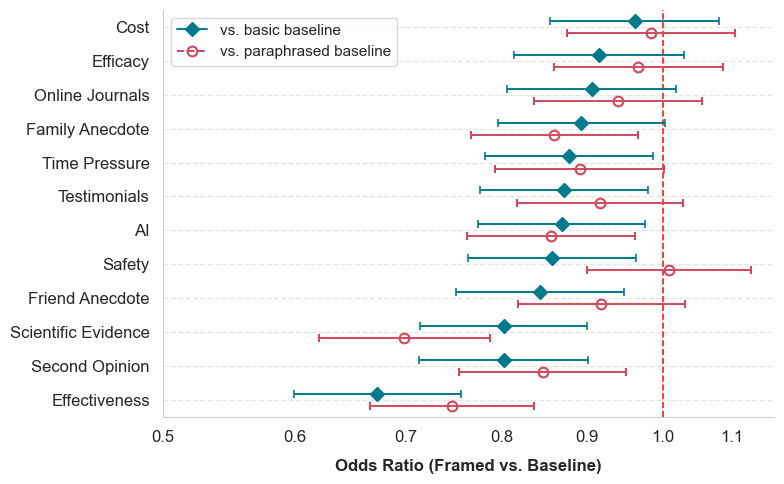

In [48]:

# Extracted (ONLY SINGLE-TURN CATEGORIES)
df = (
    pd.read_json("./outputs/analysis/data/extracted_question_category_forest_data_result_both_baselines.json")
    .loc[lambda d: ~d["question_category"].str.startswith("multiturn")]
    .assign(question_category=lambda d: d["question_category"].map(CATEGORY_LABELS))
)

# Sort order driven by Basic Baseline OR ascending
sort_order = (
    df[df["baseline_version"] == "Basic Baseline"]
    .sort_values("OR", ascending=True)["question_category"]
    .tolist()
)
y_pos   = {cat: i for i, cat in enumerate(sort_order)}
df_basic = df[df["baseline_version"] == "Basic Baseline"]
df_para  = df[df["baseline_version"] == "Paraphrased Baseline"]

OFFSET = 0.18
BLUE   = "#00798C"
RED = "#D1495B"
n_cats = len(sort_order)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for _, row in df_basic.iterrows():
    y = y_pos[row["question_category"]] + OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="D", color=BLUE, ecolor=BLUE,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        zorder=2,
    )

for _, row in df_para.iterrows():
    y = y_pos[row["question_category"]] - OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="o", color=RED, ecolor=RED,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        markerfacecolor="none", markeredgewidth=1.5,
        zorder=2,
    )

ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

ax.set_yticks(range(n_cats))
ax.set_yticklabels(sort_order, fontsize=12)
ax.set_ylim(-0.5, n_cats - 0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=BLUE, linewidth=1.4, marker="D", markersize=7,
           label="vs. basic baseline"),
    Line2D([0], [0], color=RED, linewidth=1.4, linestyle="--", marker="o",
           markersize=7, markerfacecolor="none", markeredgewidth=1.5,
           label="vs. paraphrased baseline"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True, framealpha=0.8)

x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.set_ylabel("")

sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_all_baselines/extracted_framing_effect_question_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


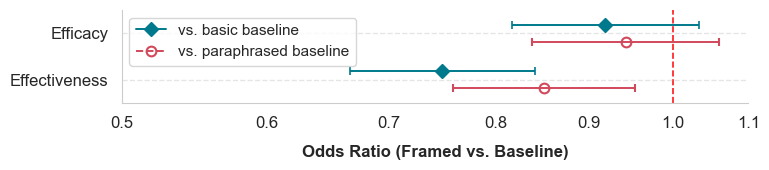

In [49]:

# Simplified
df = (
    pd.read_json("./outputs/analysis/data/simplified_question_category_forest_data_results_both_baselines.json")
    .assign(question_category=lambda d: d["question_category"].map(CATEGORY_LABELS))
)

# Sort order driven by Basic Baseline OR ascending
sort_order = (
    df[df["baseline_version"] == "Basic Baseline"]
    .sort_values("OR", ascending=True)["question_category"]
    .tolist()
)
y_pos    = {cat: i for i, cat in enumerate(sort_order)}
df_basic = df[df["baseline_version"] == "Basic Baseline"]
df_para  = df[df["baseline_version"] == "Paraphrased Baseline"]

OFFSET = 0.18
BLUE   = "#00798C"
RED = "#D1495B"
n_cats = len(sort_order)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for _, row in df_basic.iterrows():
    y = y_pos[row["question_category"]] + OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="D", color=BLUE, ecolor=BLUE,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        zorder=2,
    )

for _, row in df_para.iterrows():
    y = y_pos[row["question_category"]] - OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="o", color=RED, ecolor=RED,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        markerfacecolor="none", markeredgewidth=1.5,
        zorder=2,
    )

ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

ax.set_yticks(range(n_cats))
ax.set_yticklabels(sort_order, fontsize=12)
ax.set_ylim(-0.5, n_cats - 0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=BLUE, linewidth=1.4, marker="D", markersize=7,
           label="vs. basic baseline"),
    Line2D([0], [0], color=RED, linewidth=1.4, linestyle="--", marker="o",
           markersize=7, markerfacecolor="none", markeredgewidth=1.5,
           label="vs. paraphrased baseline"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True, framealpha=0.8)

x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.set_ylabel("")

sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout(pad=1.5)
fig.savefig(
    "../code/outputs/figures_all_baselines/simplified_framing_effect_question_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()


# Odds Ratio for Condition Category

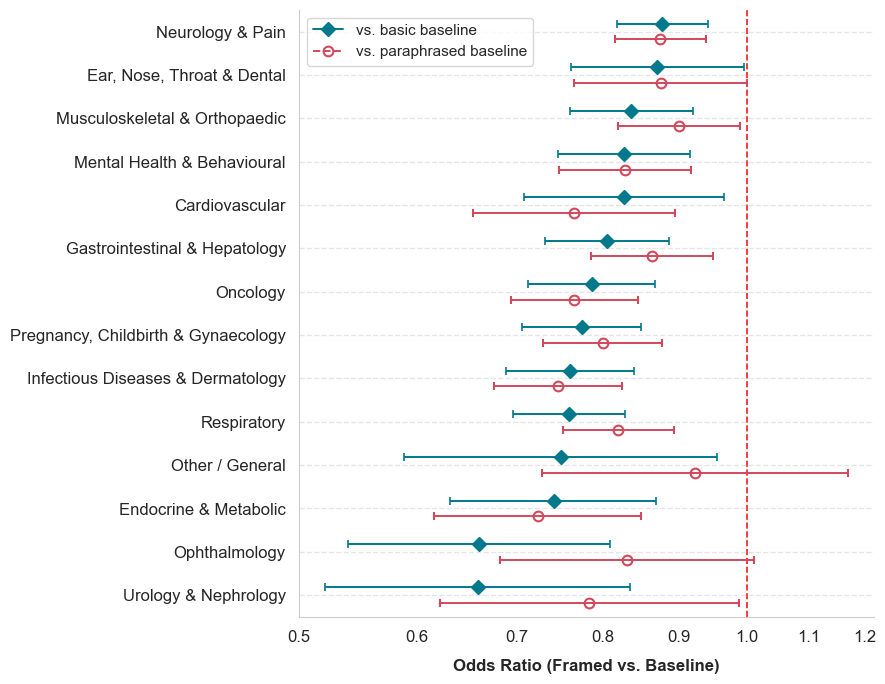

In [55]:
# Extracted
df = (
    pd.read_json("./outputs/analysis/data/extracted_condition_category_forest_data_results_both_baselines.json")
)

# Sort order driven by Basic Baseline OR ascending
sort_order = (
    df[df["baseline_version"] == "Basic Baseline"]
    .sort_values("OR", ascending=True)["condition_category"]
    .tolist()
)
y_pos   = {cat: i for i, cat in enumerate(sort_order)}
df_basic = df[df["baseline_version"] == "Basic Baseline"]
df_para  = df[df["baseline_version"] == "Paraphrased Baseline"]

OFFSET = 0.18
BLUE   = "#00798C"
RED = "#D1495B"
n_cats = len(sort_order)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for _, row in df_basic.iterrows():
    y = y_pos[row["condition_category"]] + OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="D", color=BLUE, ecolor=BLUE,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        zorder=2,
    )

for _, row in df_para.iterrows():
    y = y_pos[row["condition_category"]] - OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="o", color=RED, ecolor=RED,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        markerfacecolor="none", markeredgewidth=1.5,
        zorder=2,
    )

ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

ax.set_yticks(range(n_cats))
ax.set_yticklabels(sort_order, fontsize=12)
ax.set_ylim(-0.5, n_cats - 0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=BLUE, linewidth=1.4, marker="D", markersize=7,
           label="vs. basic baseline"),
    Line2D([0], [0], color=RED, linewidth=1.4, linestyle="--", marker="o",
           markersize=7, markerfacecolor="none", markeredgewidth=1.5,
           label="vs. paraphrased baseline"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True, framealpha=0.8)

# Axes
x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.set_ylabel("")


sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_all_baselines/extracted_framing_effect_condition_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

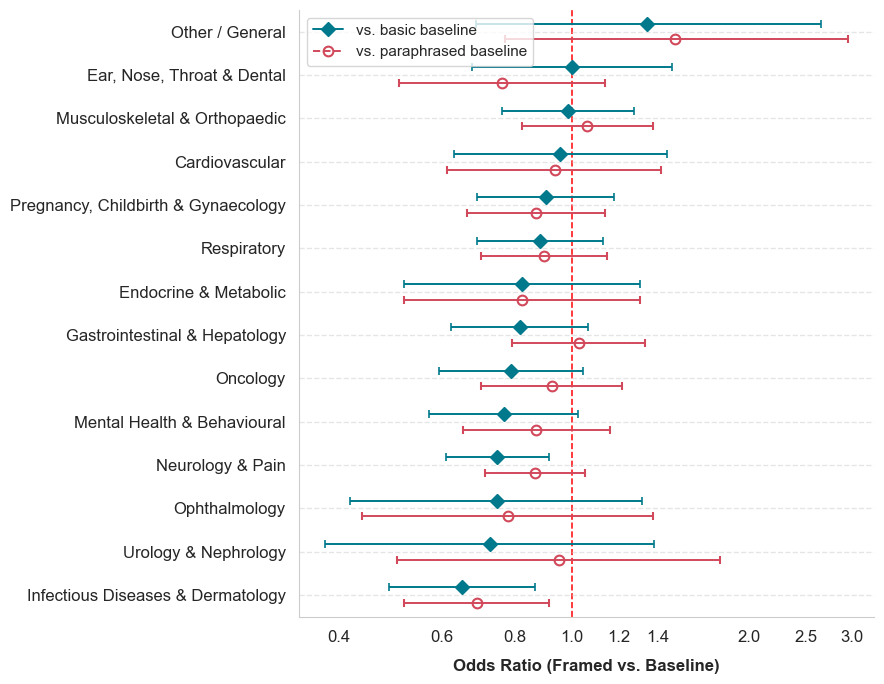

In [59]:
# Simplified
df = (
    pd.read_json("./outputs/analysis/data/simplified_condition_category_forest_data_results_both_baselines.json")
)

# Sort order driven by Basic Baseline OR ascending
sort_order = (
    df[df["baseline_version"] == "Basic Baseline"]
    .sort_values("OR", ascending=True)["condition_category"]
    .tolist()
)
y_pos   = {cat: i for i, cat in enumerate(sort_order)}
df_basic = df[df["baseline_version"] == "Basic Baseline"]
df_para  = df[df["baseline_version"] == "Paraphrased Baseline"]

OFFSET = 0.18
BLUE   = "#00798C"
RED = "#D1495B"
n_cats = len(sort_order)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for _, row in df_basic.iterrows():
    y = y_pos[row["condition_category"]] + OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="D", color=BLUE, ecolor=BLUE,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        zorder=2,
    )

for _, row in df_para.iterrows():
    y = y_pos[row["condition_category"]] - OFFSET
    ax.errorbar(
        x=row["OR"], y=y,
        xerr=[[row["OR"] - row["lower"]], [row["upper"] - row["OR"]]],
        fmt="o", color=RED, ecolor=RED,
        markersize=7, capsize=3, capthick=1.2, elinewidth=1.4,
        markerfacecolor="none", markeredgewidth=1.5,
        zorder=2,
    )

ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

ax.set_yticks(range(n_cats))
ax.set_yticklabels(sort_order, fontsize=12)
ax.set_ylim(-0.5, n_cats - 0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=BLUE, linewidth=1.4, marker="D", markersize=7,
           label="vs. basic baseline"),
    Line2D([0], [0], color=RED, linewidth=1.4, linestyle="--", marker="o",
           markersize=7, markerfacecolor="none", markeredgewidth=1.5,
           label="vs. paraphrased baseline"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True, framealpha=0.8)

# Axes
x_ticks = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 2.0, 2.5, 3.0]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.set_ylabel("")

sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_all_baselines/simplified_framing_effect_condition_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

# Interaction Effect

In [22]:
# Get review_ids that exist in BOTH technical and plain language versions
extracted = combined_df[combined_df['literacy_version'] == 'Technical']
simplified = combined_df[combined_df['literacy_version'] == 'Plain Language']
common_ids = set(extracted['review_id']).intersection(set(simplified['review_id']))

filtered_df = combined_df[combined_df['question_category'].isin(['effectiveness', 'efficacy']) & (combined_df['review_id'].isin(common_ids))]
print(filtered_df.groupby(['literacy_version', 'framing'])['agreement'].agg(['mean', 'count', 'sum']).reset_index())
# get agreement rate (percentage) for each combination of literacy_version and framing
agreement_rates = filtered_df.groupby(['literacy_version', 'framing'])['agreement'].mean().reset_index()
agreement_rates['agreement_rate'] = agreement_rates['agreement'] * 100

display(agreement_rates)

  literacy_version               framing      mean  count   sum
0   Plain Language        Basic Baseline  0.755337   5808  4387
1   Plain Language                Framed  0.718836   5808  4175
2   Plain Language  Paraphrased Baseline  0.740875   5808  4303
3        Technical        Basic Baseline  0.761364   5808  4422
4        Technical                Framed  0.714876   5808  4152
5        Technical  Paraphrased Baseline  0.747245   5808  4340


,literacy_version,framing,agreement,agreement_rate
0,Plain Language,Basic Baseline,0.755337,75.533747
1,Plain Language,Framed,0.718836,71.883609
2,Plain Language,Paraphrased Baseline,0.740875,74.087466
3,Technical,Basic Baseline,0.761364,76.136364
4,Technical,Framed,0.714876,71.487603
5,Technical,Paraphrased Baseline,0.747245,74.724518


In [29]:
def plot_interaction_effects(df: pd.DataFrame, figsize=(5, 3)):
    """
    Polished interaction plot for literacy_version and run_type.
    """
    FRAMING_ORDER = ["Basic Baseline", "Paraphrased Baseline", "Framed"]
    sns.set_theme(style="whitegrid")
    palette = {"Technical": "#00798C", "Plain Language": "#D1495B"}
    _, ax = plt.subplots(figsize=figsize)

    sns.pointplot(
        data=df,
        x="framing",
        y="agreement_rate",
        hue="literacy_version",
        palette=palette,
        markers=["o", "s"],       # distinct markers per group
        linestyles=["-", "--"],   # distinct line styles per group
        dodge=True,                          # separate overlapping points
        capsize=0.05,                        # caps on CI error bars
        err_kws={"linewidth": 1.2},
        markersize=6,
        linewidth=1.8,
        ax=ax,
        order=FRAMING_ORDER
    )

    ax.set_ylim(70, 80)
    ax.set_xlabel(None)
    ax.set_ylabel("Agreement (%)", fontsize=12, fontweight="bold")
    # ax.set_title("Agreement Rate by Run Type and Literacy Version",
    #              fontsize=12, fontweight="bold", pad=12)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda v, _: f"{v:.0%}" if v <= 1 else f"{v:.0f}"
    ))
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xticklabels(["Basic\nBaseline", "Paraphrased\nBaseline", "Framed"])

    # --- Legend ---
    ax.legend(
        title=None,
        fontsize=12,
        frameon=True,
        framealpha=0.85,
        edgecolor="lightgrey",
        loc="best",
    )

    # --- Clean up spines ---
    sns.despine(left=False, bottom=False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.savefig("./outputs/figures_all_baselines/interaction_plot.pdf", bbox_inches="tight")
    plt.show()

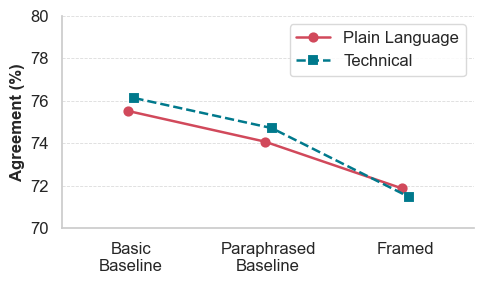

In [30]:
plot_interaction_effects(agreement_rates)

In [31]:
filtered_df = combined_df[combined_df['question_category'].isin(['effectiveness', 'efficacy']) & (combined_df['review_id'].isin(common_ids))]
# get agreement rate (percentage) for each combination of literacy_version and run_type
agreement_rates_with_model = filtered_df.groupby(['literacy_version', 'framing', 'model'])['agreement'].mean().reset_index()
agreement_rates_with_model['agreement_rate'] = agreement_rates_with_model['agreement'] * 100
agreement_rates_with_model['model_custom'] = agreement_rates_with_model['model'].map(MODEL_LABELS_NEWLINE)

display(agreement_rates_with_model)

,literacy_version,framing,model,agreement,agreement_rate,model_custom
0,Plain Language,Basic Baseline,api-llama3.3,0.775482,77.548209,Llama 3.3 70B
1,Plain Language,Basic Baseline,api-llama4,0.787879,78.787879,Llama 4\nMaverick 17B
2,Plain Language,Basic Baseline,claude_4.5_sonnet,0.736915,73.691460,Claude\nSonnet 4.5
3,Plain Language,Basic Baseline,gpt-5.1,0.743802,74.380165,GPT 5.1
4,Plain Language,Basic Baseline,huatuo-7B,0.735537,73.553719,HuatuoGPT 7B
5,Plain Language,Basic Baseline,huatuo-8B,0.720386,72.038567,HuatuoGPT 8B
6,Plain Language,Basic Baseline,qwen3-30B,0.778237,77.823691,Qwen3 30B
7,Plain Language,Basic Baseline,qwen3-4B,0.764463,76.446281,Qwen3 4B
8,Plain Language,Framed,api-llama3.3,0.719008,71.900826,Llama 3.3 70B
9,Plain Language,Framed,api-llama4,0.731405,73.140496,Llama 4\nMaverick 17B


In [34]:
import math

def plot_interaction_effects_all_models(df: pd.DataFrame, figsize=(14, 6)):
    """Faceted interaction plot for literacy_version and framing across all models."""
    sns.set_theme(style="whitegrid")
    FRAMING_ORDER = ["Basic Baseline", "Paraphrased Baseline", "Framed"]
    palette = {"Technical": "#00798C", "Plain Language": "#D1495B"}
    models = sorted(df["model_custom"].unique())
    n_cols = 4
    n_rows = math.ceil(len(models) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True, sharex=True)
    axes_flat = axes.flatten()

    for i, (ax, model) in enumerate(zip(axes_flat, models)):
        sns.pointplot(
            data=df[df["model_custom"] == model],
            x="framing", y="agreement_rate", hue="literacy_version",
            palette=palette, markers=["o", "s"], linestyles=["-", "--"],
            dodge=0.2, capsize=0.1, err_kws={"linewidth": 1.5},
            markersize=6, linewidth=2.0, ax=ax, legend=(i == 0), order=FRAMING_ORDER
        )
        ax.set(title=model, xlabel=None, ylim=(67.5, 80),
               ylabel="Agreement (%)" if i % n_cols == 0 else None)
        ax.set_ylabel("Agreement (%)", fontsize=14, fontweight="bold")
        ax.title.set(fontsize=14, fontweight="bold")
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(
            lambda v, _: f"{v:.0%}" if v <= 1 else f"{v:.1f}"
        ))
        ax.tick_params(axis="both", labelsize=14)
        ax.set_xticklabels(["Basic\nBaseline", "Paraphrased\nBaseline", "Framed"])
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
        ax.grid(axis="x", visible=False)
        sns.despine(ax=ax)

    # Hide unused subplots
    for ax in axes_flat[len(models):]:
        ax.set_visible(False)

    # --- Reposition legend from first panel to figure level ---
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if axes_flat[0].get_legend():
        axes_flat[0].get_legend().remove()

    fig.legend(
        handles, labels,
        title=None,                      # drop title to save space
        fontsize=14,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),     # centered just below the plots
        ncol=len(labels),                # all items in one horizontal line
        columnspacing=1.5,
        handlelength=2.0,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig("./outputs/figures/interaction_plot_all_models.pdf", bbox_inches="tight")
    plt.show()

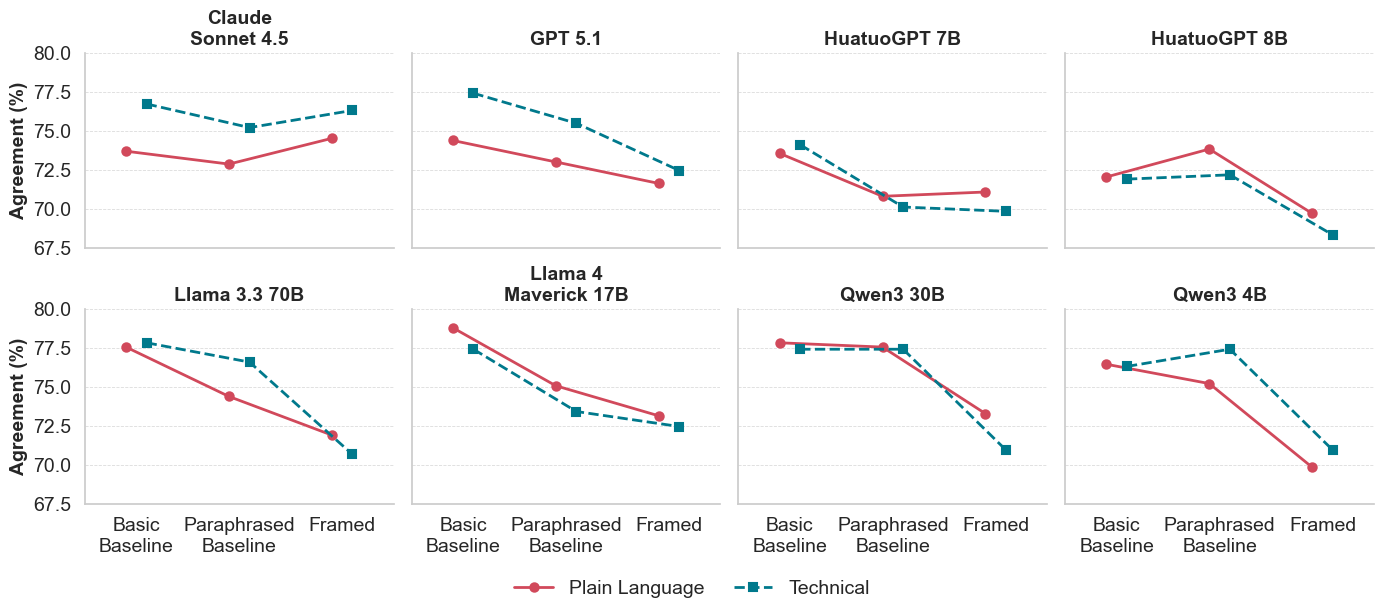

In [35]:
plot_interaction_effects_all_models(agreement_rates_with_model)